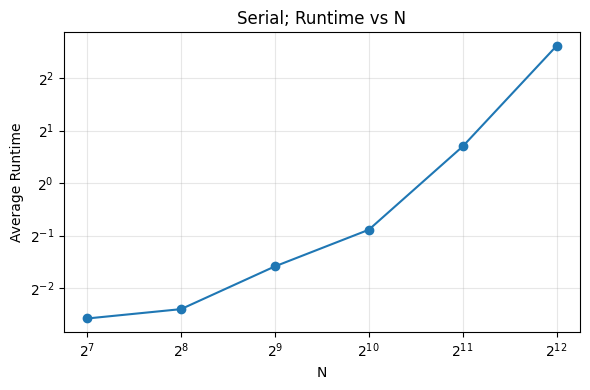

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (assumes columns: N, runtime)
data_serial = pd.read_csv("nbody_serial_runtimes.txt", delimiter=",", header=None)

# Keep first two columns and name them
data_serial = data_serial.iloc[:, [0, 2]]
data_serial.columns = ["N", "runtime"]

# Convert columns to numeric (invalid values become NaN)
data_serial["N"] = pd.to_numeric(data_serial["N"], errors="coerce")
data_serial["runtime"] = pd.to_numeric(data_serial["runtime"], errors="coerce")

# Compute average runtime for each N
avg_runtimes = data_serial.groupby("N", as_index=False)["runtime"].mean().sort_values("N")

# Plot average runtime vs N
plt.figure(figsize=(6, 4))
plt.plot(avg_runtimes["N"], avg_runtimes["runtime"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("N")
plt.ylabel("Average Runtime")
plt.title("Serial; Runtime vs N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

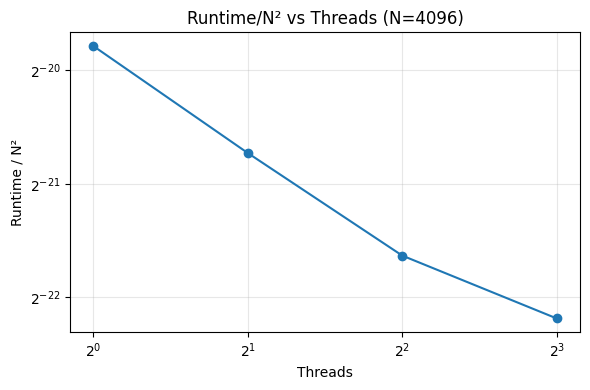

In [2]:
# Load OMP data
data_omp = pd.read_csv("nbody_omp_runtimes.txt", delimiter=",", header=None)

# Keep first three columns and name them
data_omp = data_omp.iloc[:, [0, 1, 2]]
data_omp.columns = ["N", "threads", "runtime"]

# Convert columns to numeric
data_omp["N"] = pd.to_numeric(data_omp["N"], errors="coerce")
data_omp["threads"] = pd.to_numeric(data_omp["threads"], errors="coerce")
data_omp["runtime"] = pd.to_numeric(data_omp["runtime"], errors="coerce")

# Filter for selected_N and compute runtime/N^2
selected_N = data_omp["N"].max()  # Use the largest N available in the OMP data
runtimes_for_N_omp = data_omp[data_omp["N"] == selected_N].copy()
runtimes_for_N_omp["runtime_over_N2"] = runtimes_for_N_omp["runtime"] / (selected_N ** 2)

# Plot runtime/N^2 vs threads
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_omp["threads"], runtimes_for_N_omp["runtime_over_N2"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Threads (N={int(selected_N)})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

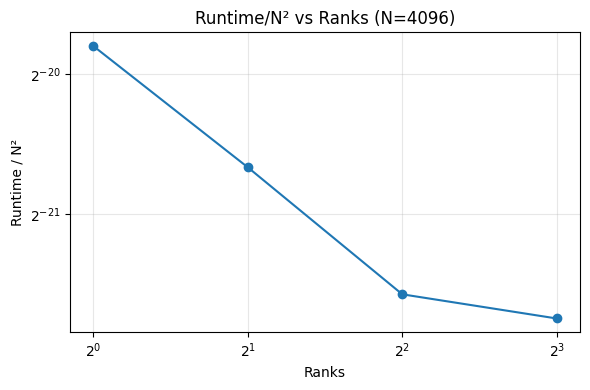

In [3]:
# Load MPI data
data_mpi = pd.read_csv("nbody_mpi_runtimes.txt", delimiter=",", header=None)

# Keep first three columns and name them
data_mpi = data_mpi.iloc[:, [0, 1, 2]]
data_mpi.columns = ["N", "ranks", "runtime"]

# Convert columns to numeric
data_mpi["N"] = pd.to_numeric(data_mpi["N"], errors="coerce")
data_mpi["ranks"] = pd.to_numeric(data_mpi["ranks"], errors="coerce")
data_mpi["runtime"] = pd.to_numeric(data_mpi["runtime"], errors="coerce")

# Filter for selected_N and compute runtime/N^2
selected_N = data_mpi["N"].max()  # Use the largest N available in the MPI data
runtimes_for_N_mpi = data_mpi[data_mpi["N"] == selected_N].copy()
runtimes_for_N_mpi["runtime_over_N2"] = runtimes_for_N_mpi["runtime"] / (selected_N ** 2)

# Plot runtime/N^2 vs threads
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_mpi["ranks"], runtimes_for_N_mpi["runtime_over_N2"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Ranks (N={int(selected_N)})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

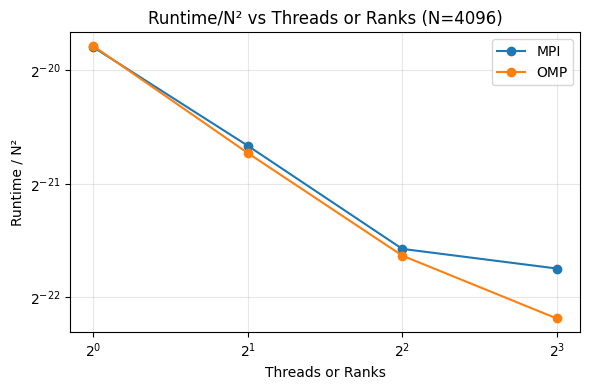

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(runtimes_for_N_mpi["ranks"], runtimes_for_N_mpi["runtime_over_N2"], marker="o", label="MPI")
plt.plot(runtimes_for_N_omp["threads"], runtimes_for_N_omp["runtime_over_N2"], marker="o", label="OMP")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads or Ranks")
plt.ylabel("Runtime / N²")
plt.title(f"Runtime/N² vs Threads or Ranks (N={int(selected_N)})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/m4/897tzq815kn38r2838pxyf2m0000gn/T/ipykernel_23162/732652418.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


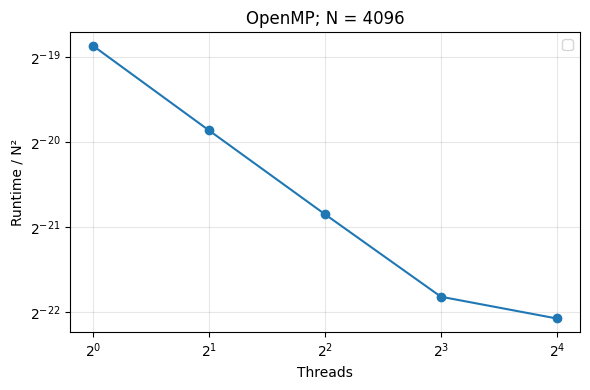

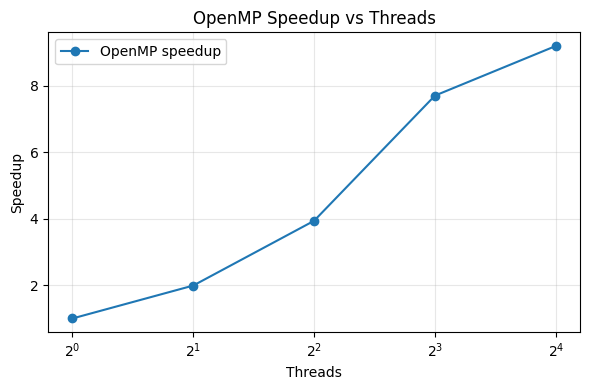

In [17]:
from pathlib import Path

# Cell 1: Load serial data
base_path = "hw5/hpc_results"

file_path = Path(base_path) / "nbody_omp_runtimes_strong.txt"
if not file_path.exists():
    file_path = Path("hpc_results") / "nbody_omp_runtimes_strong.txt"

data_omp_hpc = pd.read_csv(file_path, delimiter=",", header=None)
data_omp_hpc = data_omp_hpc.iloc[:, [0,1, 2]]
data_omp_hpc.columns = ["N", "threads", "runtime"]

data_omp_hpc["N"] = pd.to_numeric(data_omp_hpc["N"], errors="coerce")
data_omp_hpc["threads"] = pd.to_numeric(data_omp_hpc["threads"], errors="coerce")
data_omp_hpc["runtime"] = pd.to_numeric(data_omp_hpc["runtime"], errors="coerce")
data_omp_hpc = data_omp_hpc.dropna(subset=["N", "threads", "runtime"])
# No averaging: each row is already a distinct thread-count run
avg_runtimes = data_omp_hpc.sort_values("threads").reset_index(drop=True)
avg_runtimes["runtime_over_N2"] = avg_runtimes["runtime"] / (avg_runtimes["N"] ** 2)

plt.figure(figsize=(6, 4))
plt.plot(data_omp_hpc["threads"], avg_runtimes["runtime_over_N2"], marker="o")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads")
plt.ylabel("Runtime / N²")
plt.title("OpenMP; N = 4096")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot speedup vs number of threads (OpenMP)
speedup_omp = avg_runtimes[["threads", "runtime"]].sort_values("threads").copy()
t1_omp = speedup_omp.loc[speedup_omp["threads"] == 1, "runtime"].iloc[0]
speedup_omp["speedup"] = t1_omp / speedup_omp["runtime"]

plt.figure(figsize=(6, 4))
plt.plot(speedup_omp["threads"], speedup_omp["speedup"], marker="o", label="OpenMP speedup")
plt.xscale("log", base=2)
plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.title("OpenMP Speedup vs Threads")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

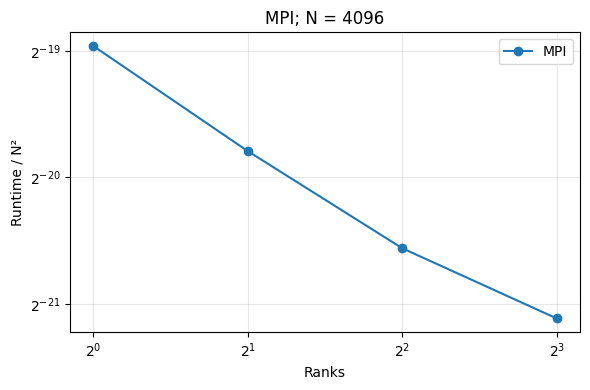

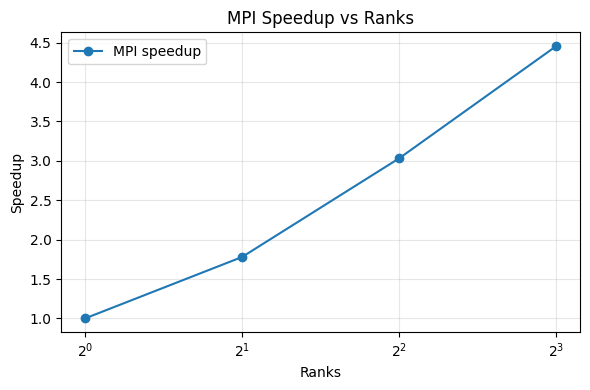

In [18]:
# Load MPI strong-scaling data
file_path = Path(base_path) / "nbody_mpi_runtimes_strong.txt"
if not file_path.exists():
    file_path = Path("hpc_results") / "nbody_mpi_runtimes_strong.txt"

data_mpi_hpc = pd.read_csv(file_path, delimiter=",", header=None)
data_mpi_hpc = data_mpi_hpc.iloc[:, [0, 1, 2]]
data_mpi_hpc.columns = ["N", "ranks", "runtime"]

data_mpi_hpc["N"] = pd.to_numeric(data_mpi_hpc["N"], errors="coerce")
data_mpi_hpc["ranks"] = pd.to_numeric(data_mpi_hpc["ranks"], errors="coerce")
data_mpi_hpc["runtime"] = pd.to_numeric(data_mpi_hpc["runtime"], errors="coerce")
data_mpi_hpc = data_mpi_hpc.dropna(subset=["N", "ranks", "runtime"])

# No averaging: each row is already a distinct rank-count run
avg_runtimes_mpi = data_mpi_hpc.sort_values("ranks").reset_index(drop=True)
avg_runtimes_mpi["runtime_over_N2"] = avg_runtimes_mpi["runtime"] / (avg_runtimes_mpi["N"] ** 2)

plt.figure(figsize=(6, 4))
plt.plot(avg_runtimes_mpi["ranks"], avg_runtimes_mpi["runtime_over_N2"], marker="o", label="MPI")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Runtime / N²")
plt.title("MPI; N = 4096")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot speedup vs number of ranks (MPI)
speedup_mpi = avg_runtimes_mpi[["ranks", "runtime"]].sort_values("ranks").copy()
t1_mpi = speedup_mpi.loc[speedup_mpi["ranks"] == 1, "runtime"].iloc[0]
speedup_mpi["speedup"] = t1_mpi / speedup_mpi["runtime"]

plt.figure(figsize=(6, 4))
plt.plot(speedup_mpi["ranks"], speedup_mpi["speedup"], marker="o", label="MPI speedup")
plt.xscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Speedup")
plt.title("MPI Speedup vs Ranks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

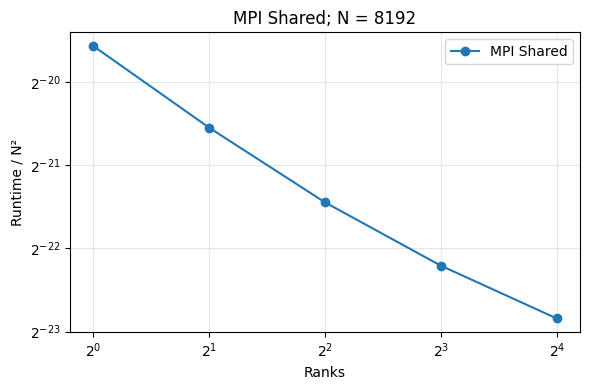

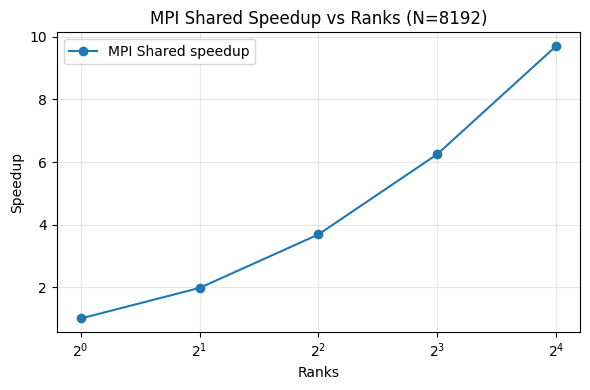

In [19]:
# Load MPI shared-memory scaling data
file_path = Path(base_path) / "nbody_mpi_shared_runtimes.txt"
if not file_path.exists():
    file_path = Path("hpc_results") / "nbody_mpi_shared_runtimes.txt"

data_mpi_shared = pd.read_csv(file_path, delimiter=",", header=None)
data_mpi_shared = data_mpi_shared.iloc[:, [0, 1, 2]]
data_mpi_shared.columns = ["N", "ranks", "runtime"]

data_mpi_shared["N"] = pd.to_numeric(data_mpi_shared["N"], errors="coerce")
data_mpi_shared["ranks"] = pd.to_numeric(data_mpi_shared["ranks"], errors="coerce")
data_mpi_shared["runtime"] = pd.to_numeric(data_mpi_shared["runtime"], errors="coerce")
data_mpi_shared = data_mpi_shared.dropna(subset=["N", "ranks", "runtime"])

avg_runtimes_mpi_shared = data_mpi_shared.sort_values("ranks").reset_index(drop=True)
avg_runtimes_mpi_shared["runtime_over_N2"] = (
    avg_runtimes_mpi_shared["runtime"] / (avg_runtimes_mpi_shared["N"] ** 2)
)

plt.figure(figsize=(6, 4))
plt.plot(
    avg_runtimes_mpi_shared["ranks"],
    avg_runtimes_mpi_shared["runtime_over_N2"],
    marker="o",
    label="MPI Shared",
)
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Runtime / N²")
plt.title(f"MPI Shared; N = {int(avg_runtimes_mpi_shared['N'].iloc[0])}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Plot speedup vs number of ranks (MPI shared-memory)
speedup_mpi_shared = avg_runtimes_mpi_shared[["ranks", "runtime"]].sort_values("ranks").copy()
t1_mpi_shared = speedup_mpi_shared.loc[speedup_mpi_shared["ranks"] == 1, "runtime"].iloc[0]
speedup_mpi_shared["speedup"] = t1_mpi_shared / speedup_mpi_shared["runtime"]

plt.figure(figsize=(6, 4))
plt.plot(
    speedup_mpi_shared["ranks"],
    speedup_mpi_shared["speedup"],
    marker="o",
    label="MPI Shared speedup",
)
plt.xscale("log", base=2)
plt.xlabel("Ranks")
plt.ylabel("Speedup")
plt.title(f"MPI Shared Speedup vs Ranks (N={int(avg_runtimes_mpi_shared['N'].iloc[0])})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


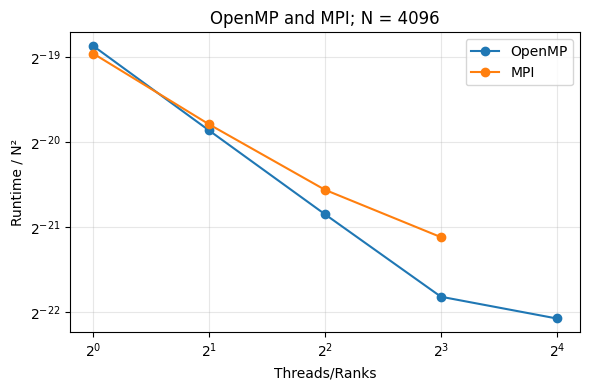

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(data_omp_hpc["threads"], avg_runtimes["runtime_over_N2"], marker="o", label="OpenMP")
plt.plot(avg_runtimes_mpi["ranks"], avg_runtimes_mpi["runtime_over_N2"], marker="o", label="MPI")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("Threads/Ranks")
plt.ylabel("Runtime / N²")
plt.title("OpenMP and MPI; N = 4096")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()